- Basic Market Statistics -
Mean (Average) Price: Rp 5,220,718,646
Median (Middle) Price: Rp 1,500,000,000

- Identifying Outliers (Min & Max) -
Cheapest House: Rp 1
Most Expensive House: Rp 999,000,000,000

- Summary -
          price_clean  land_area_clean  bedrooms_clean
count          38,695           38,695          33,518
mean    5,220,718,646           37,173               3
std    29,877,831,958        4,522,003               2
min                 1                1               1
25%       800,000,000               72               2
50%     1,500,000,000              115               3
75%     3,500,000,000              285               4
max   999,000,000,000      818,801,098              20
- Outlier Detection (Price) -
Normal Price Range: Rp -3,250,000,000 to Rp 7,550,000,000

Original Rows: 38695
Rows after trimming: 34808
Removed 3887 extreme outliers!


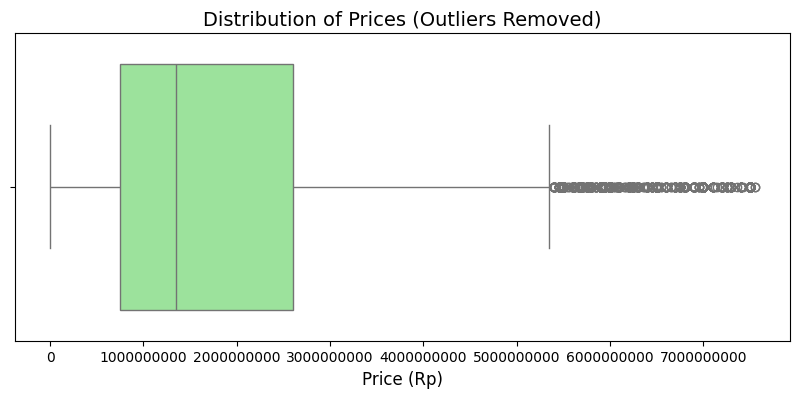

--- Market Segmentation (Property Tiers) ---

What does a typical (Median) house look like in each tier?
             price_clean_formatted  bedrooms_clean  land_area_clean  \
market_tier                                                           
1. Budget           Rp 489,000,000               2               65   
2. Mid-Range      Rp 1,350,000,000               3              100   
3. Luxury         Rp 3,970,000,000               4              300   

              building_area_clean  
market_tier                        
1. Budget                      45  
2. Mid-Range                  100  
3. Luxury                     250  


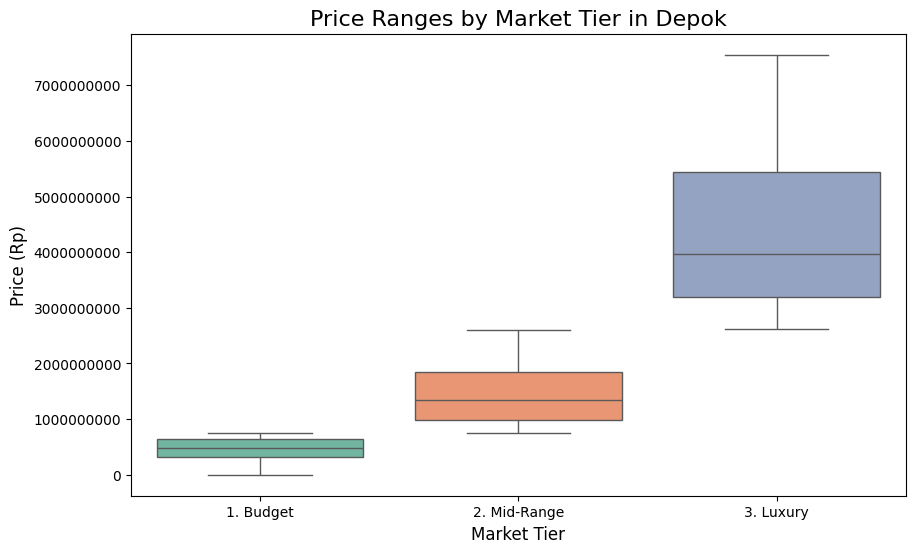

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/whrizkey/DepokPropertyPrices/main/data/processed/Cleaned-Rumah-Depok.csv'
df = pd.read_csv(url)

pd.options.display.float_format = '{:,.0f}'.format

print("- Basic Market Statistics -")

mean_price = df['price_clean'].mean()
median_price = df['price_clean'].median()

print(f"Mean (Average) Price: Rp {mean_price:,.0f}")
print(f"Median (Middle) Price: Rp {median_price:,.0f}")

print("\n- Identifying Outliers (Min & Max) -")

cheapest_house = df['price_clean'].min()
most_expensive = df['price_clean'].max()

print(f"Cheapest House: Rp {cheapest_house:,.0f}")
print(f"Most Expensive House: Rp {most_expensive:,.0f}")

# .describe()

print("\n- Summary -")
print(df[['price_clean', 'land_area_clean', 'bedrooms_clean']].describe())


#Correlation
print("- Outlier Detection (Price) -")

#Calculate Q1 and Q3
Q1 = df['price_clean'].quantile(0.25)
Q3 = df['price_clean'].quantile(0.75)
IQR = Q3 - Q1

# 1.5 * IQR statistical rule for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Normal Price Range: Rp {lower_bound:,.0f} to Rp {upper_bound:,.0f}")

# Filter the DataFrame to keep only the rows within the boundaries
df_filtered = df[(df['price_clean'] >= lower_bound) & (df['price_clean'] <= upper_bound)].copy()

total_original = len(df)
total_filtered = len(df_filtered)
trimmed_amount = total_original - total_filtered

print(f"\nOriginal Rows: {total_original}")
print(f"Rows after trimming: {total_filtered}")
print(f"Removed {trimmed_amount} extreme outliers!")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_filtered['price_clean'], color='lightgreen')
plt.title('Distribution of Prices (Outliers Removed)', fontsize=14)
plt.xlabel('Price (Rp)', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.show()


# Market Segmentation


print("--- Market Segmentation (Property Tiers) ---")

# Define the tiers based on filtered data
labels = ['1. Budget', '2. Mid-Range', '3. Luxury']
bins = [0, 0.25, 0.75, 1.0]

df_filtered['market_tier'] = pd.qcut(df_filtered['price_clean'], q=bins, labels=labels)

# A typical house look like in each tier?
tier_analysis = df_filtered.groupby('market_tier', observed=False)[['price_clean', 'bedrooms_clean', 'land_area_clean', 'building_area_clean']].median()

tier_analysis['price_clean_formatted'] = tier_analysis['price_clean'].apply(lambda x: f"Rp {x:,.0f}")

print("\nWhat does a typical (Median) house look like in each tier?")

print(tier_analysis[['price_clean_formatted', 'bedrooms_clean', 'land_area_clean', 'building_area_clean']])

# Visualize
plt.figure(figsize=(10, 6))
sns.boxplot(x='market_tier', y='price_clean', data=df_filtered, hue='market_tier', legend=False, palette='Set2')

plt.title('Price Ranges by Market Tier in Depok', fontsize=16)
plt.xlabel('Market Tier', fontsize=12)
plt.ylabel('Price (Rp)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') # No scientific notation
plt.show()